# Visualize Image Gradients

This notebook provides a utility to visualize the image gradients (edge information). Gradients can help highlight artifact differences between real and AI-generated images, similarly to the frequency spectrum.

In [2]:
import torch
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import os

In [3]:
def get_grayscale(x):
    # Convert RGB inputs (nominally normalized) to grayscale
    # Using BT.601 standard photometric weights
    return 0.299 * x[:, 0:1, :, :] + 0.587 * x[:, 1:2, :, :] + 0.114 * x[:, 2:3, :, :]

def compute_gradients(gray):
    # Define Sobel filters to compute gradients in x and y directions
    sobel_x = torch.tensor([[-1., 0., 1.], [-2., 0., 2.], [-1., 0., 1.]]).view(1, 1, 3, 3).to(gray.device)
    sobel_y = torch.tensor([[-1., -2., -1.], [0., 0., 0.], [1., 2., 1.]]).view(1, 1, 3, 3).to(gray.device)
    
    # Extract gradients using convolution
    G_x = F.conv2d(gray, sobel_x, padding=1)
    G_y = F.conv2d(gray, sobel_y, padding=1)
    
    # Calculate gradient magnitude
    magnitude = torch.sqrt(G_x**2 + G_y**2)
    return magnitude

def visualize_gradients(image_path):
    if not os.path.exists(image_path):
        print(f"Error: {image_path} not found.")
        return
        
    # Load and preprocess image
    image = Image.open(image_path).convert('RGB')
    
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor()
    ])
    
    img_tensor = transform(image).unsqueeze(0)
    
    # Apply model transformations
    with torch.no_grad():
        gray_tensor = get_grayscale(img_tensor)
        grad_tensor = compute_gradients(gray_tensor)
        
    # Prepare for visualization
    img_disp = img_tensor[0].permute(1, 2, 0).numpy()
    gray_disp = gray_tensor[0, 0].numpy()
    grad_disp = grad_tensor[0, 0].numpy()
    
    # Plotting
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].imshow(img_disp)
    axes[0].set_title("Original Image (Resized)")
    axes[0].axis("off")
    
    axes[1].imshow(gray_disp, cmap='gray')
    axes[1].set_title("Grayscale (BT.601)")
    axes[1].axis("off")
    
    # Gradient magnitude is typically visualized nicely with 'magma' or 'hot'
    c1 = axes[2].imshow(grad_disp, cmap='magma')
    axes[2].set_title("Gradient Magnitude")
    axes[2].axis("off")
    fig.colorbar(c1, ax=axes[2], fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    plt.show()

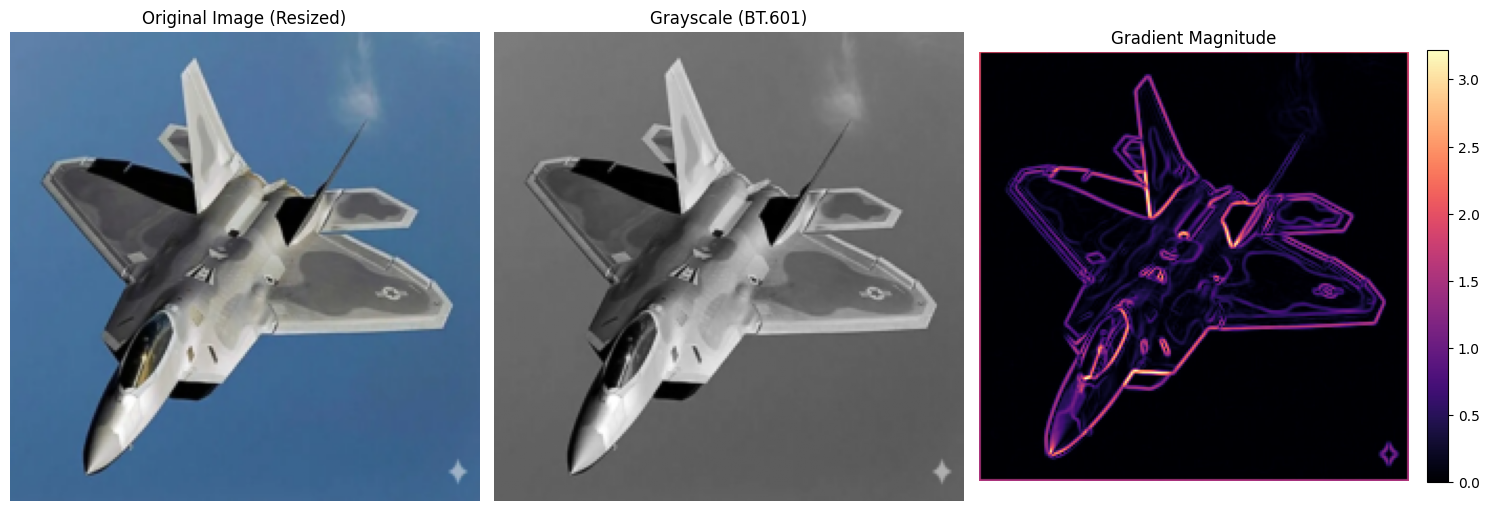

In [4]:
# Example usage:
visualize_gradients('../test/fakef22.webp')

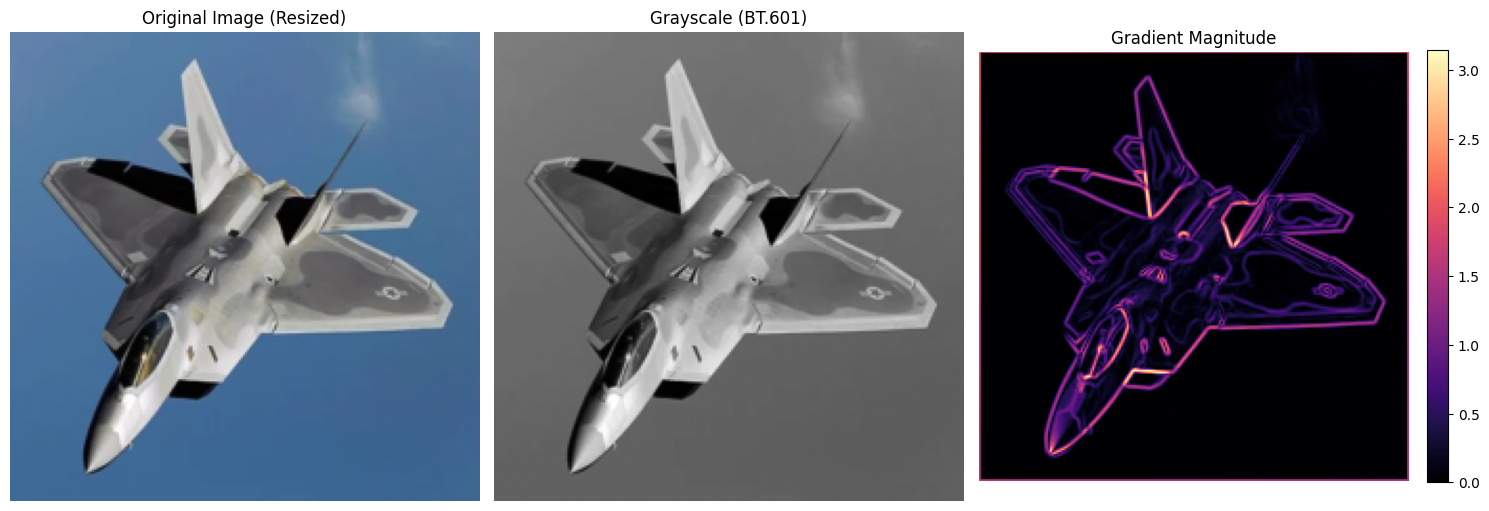

In [5]:
visualize_gradients('../test/realf22.jpg')

# Compare Real vs Fake Image Gradients
This function takes two images (one real, one fake), scales them to the same size, computes their gradient magnitudes, and visualizes the absolute difference between them.

In [6]:
def compare_gradients(real_image_path, fake_image_path):
    if not os.path.exists(real_image_path):
        print(f"Error: Real image {real_image_path} not found.")
        return
    if not os.path.exists(fake_image_path):
        print(f"Error: Fake image {fake_image_path} not found.")
        return
        
    # Resize to the same dimensions for a 1-to-1 subtraction
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor()
    ])
    
    # Load and process Images
    real_img = Image.open(real_image_path).convert('RGB')
    fake_img = Image.open(fake_image_path).convert('RGB')
    
    real_tensor = transform(real_img).unsqueeze(0)
    fake_tensor = transform(fake_img).unsqueeze(0)
    
    with torch.no_grad():
        # Compute grayscale
        real_gray = get_grayscale(real_tensor)
        fake_gray = get_grayscale(fake_tensor)
        
        # Compute gradients
        real_grad = compute_gradients(real_gray)
        fake_grad = compute_gradients(fake_gray)
        
        # Calculate absolute difference between gradient magnitudes
        diff_grad = torch.abs(real_grad - fake_grad)
        
    # Prepare Numpy arrays for plotting
    real_disp_img = real_tensor[0].permute(1, 2, 0).numpy()
    fake_disp_img = fake_tensor[0].permute(1, 2, 0).numpy()
    
    real_disp_grad = real_grad[0, 0].numpy()
    fake_disp_grad = fake_grad[0, 0].numpy()
    diff_disp_grad = diff_grad[0, 0].numpy()
    
    # Plotting
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # Plot Real Image & Gradients
    axes[0, 0].imshow(real_disp_img)
    axes[0, 0].set_title("Real Image (Resized)")
    axes[0, 0].axis("off")
    
    c_real = axes[0, 1].imshow(real_disp_grad, cmap='magma')
    axes[0, 1].set_title("Real Gradient Magnitude")
    axes[0, 1].axis("off")
    fig.colorbar(c_real, ax=axes[0, 1], fraction=0.046, pad=0.04)
    
    # Plot Difference
    c_diff = axes[0, 2].imshow(diff_disp_grad, cmap='inferno') # Heatmap for differences
    axes[0, 2].set_title("Absolute Difference in Gradients")
    axes[0, 2].axis("off")
    fig.colorbar(c_diff, ax=axes[0, 2], fraction=0.046, pad=0.04)
    
    # Plot Fake Image & Gradients
    axes[1, 0].imshow(fake_disp_img)
    axes[1, 0].set_title("Fake Image (Resized)")
    axes[1, 0].axis("off")
    
    c_fake = axes[1, 1].imshow(fake_disp_grad, cmap='magma')
    axes[1, 1].set_title("Fake Gradient Magnitude")
    axes[1, 1].axis("off")
    fig.colorbar(c_fake, ax=axes[1, 1], fraction=0.046, pad=0.04)
    
    # Empty bottom-right plot
    axes[1, 2].axis("off")
    
    plt.tight_layout()
    plt.show()

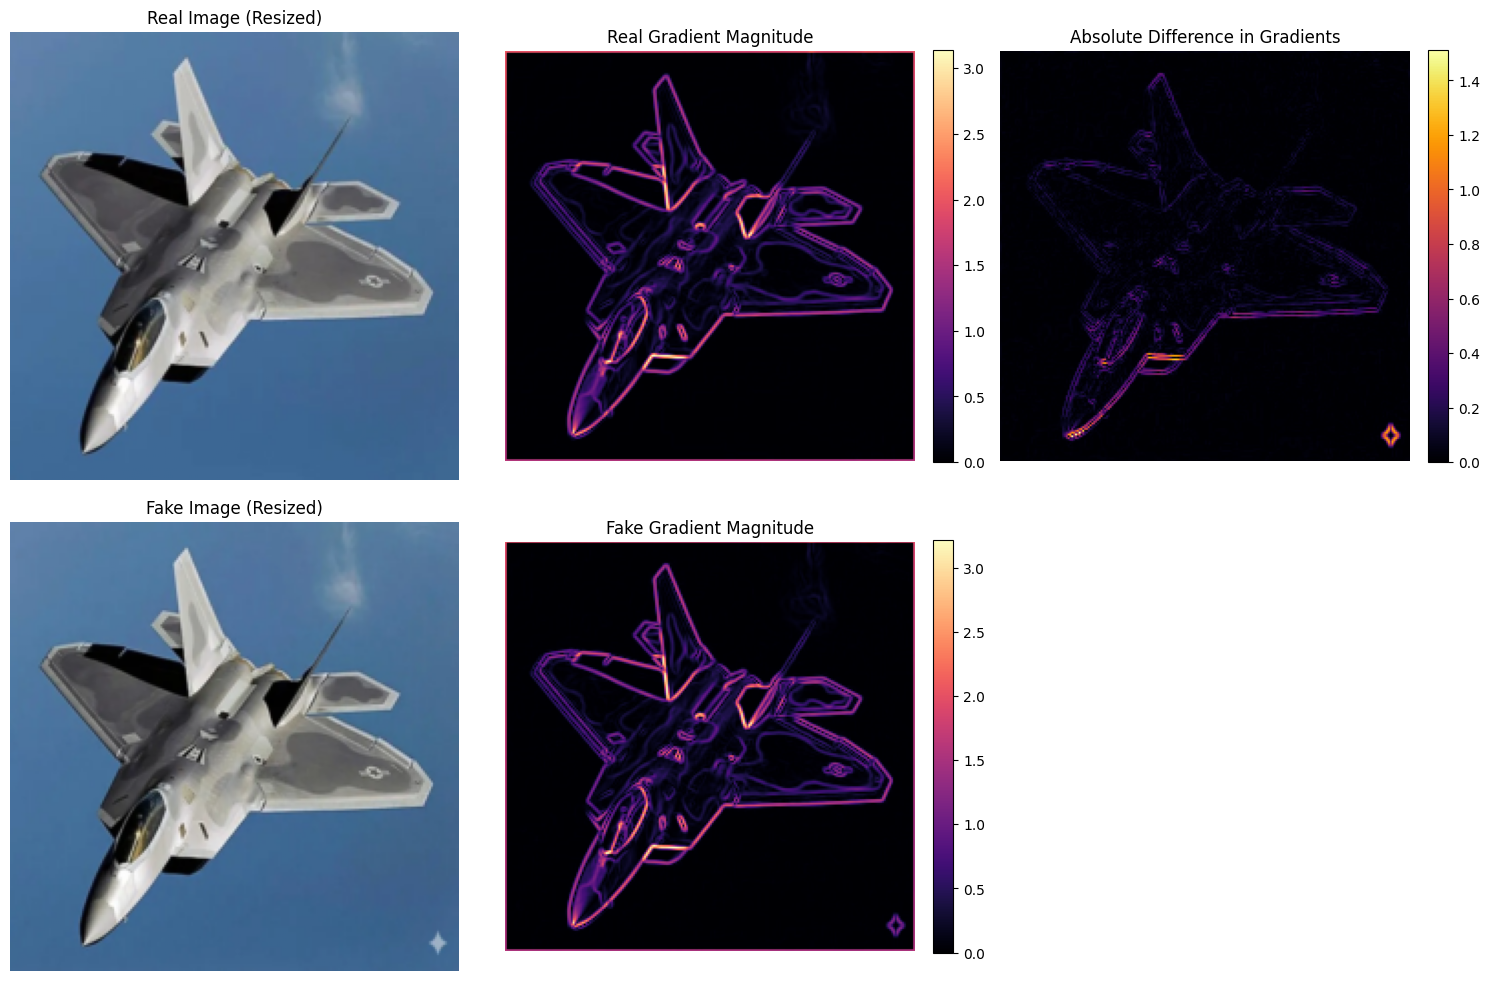

In [7]:
real_path = '../test/realf22.jpg'
fake_path = '../test/fakef22.webp'
compare_gradients(real_path, fake_path)